In [1]:
%pip install pandas joblib numpy scikit-learn fairlearn matplotlib seaborn aif360 lime shap dice-ml ipywidgets patra_toolkit

import pandas as pd

url = "https://raw.githubusercontent.com/CDEIUK/bias-mitigation/refs/heads/master/artifacts/data/recruiting/processed/train.csv"

test = pd.read_csv(url)
print(test.head())
print(len(test))

Note: you may need to restart the kernel to use updated packages.
   sex_male  race_white  years_experience  referred      gcse   a_level  \
0         0           1          0.265328         1  0.148817  1.115547   
1         0           1         -1.126253         0  0.148817  1.115547   
2         1           0         -0.082567         1  0.148817 -1.013021   
3         1           1          0.265328         1 -1.065188  0.051263   
4         1           1         -0.778358         1 -1.065188  0.051263   

   russell_group  honours  years_volunteer    income  it_skills  years_gaps  \
0              1        1         2.139888 -0.740776  -0.712629    1.428393   
1              1        1        -0.704762 -0.229262   0.363037   -0.704067   
2              0        0        -0.704762 -1.325363  -1.788296   -0.704067   
3              0        0        -0.704762  1.414890   0.363037    0.362163   
4              0        0         0.717563  0.757230   1.438704   -0.704067   

   quali

In [2]:
# White and employed
whiteEmployed_df = test[(test['race_white'] == 1) & (test['employed_yes'] == 1)]

whiteEmployed_df_count = len(whiteEmployed_df)

print(f"White and employed: {whiteEmployed_df_count}")

White and employed: 1611


In [3]:
# Colored and employed
whiteEmployed_df = test[(test['race_white'] == 0) & (test['employed_yes'] == 1)]

whiteEmployed_df_count = len(whiteEmployed_df)

print(f"Colored and employed: {whiteEmployed_df_count}")

Colored and employed: 674


In [4]:
# Male ve employed
whiteEmployed_df = test[(test['sex_male'] == 1) & (test['employed_yes'] == 1)]

whiteEmployed_df_count = len(whiteEmployed_df)

print(f"Male and employed: {whiteEmployed_df_count}")

Male and employed: 1401


In [5]:
# Female ve employed
whiteEmployed_df = test[(test['sex_male'] == 0) & (test['employed_yes'] == 1)]

whiteEmployed_df_count = len(whiteEmployed_df)

print(f"Female and employed: {whiteEmployed_df_count}")

Female and employed: 884


In [6]:
employed_by_sex = test[["sex_male", "employed_yes"]].groupby("sex_male").mean()
print(employed_by_sex)


          employed_yes
sex_male              
0             0.295159
1             0.466223


In [7]:
employed_by_race = test[["race_white", "employed_yes"]].groupby("race_white").mean()
print(employed_by_race)


            employed_yes
race_white              
0               0.230743
1               0.523222


In [8]:
cv_by_race = test[["race_white", "quality_cv"]].groupby("race_white").mean()
print(cv_by_race)


            quality_cv
race_white            
0             0.006184
1            -0.005866


In [9]:
cv_by_sex = test[["sex_male", "quality_cv"]].groupby("sex_male").mean()
print(cv_by_sex)


          quality_cv
sex_male            
0           0.009956
1          -0.009923


In [10]:
from pathlib import Path
import joblib


from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    equalized_odds_ratio,
)

In [11]:
test_url = "https://raw.githubusercontent.com/CDEIUK/bias-mitigation/refs/heads/master/artifacts/data/recruiting/processed/test.csv"
test = pd.read_csv(test_url)
test_raw_url = "https://raw.githubusercontent.com/CDEIUK/bias-mitigation/refs/heads/master/artifacts/data/recruiting/raw/test.csv"
test_raw = pd.read_csv(test_raw_url)

model = joblib.load("baseline.pkl")

c:\Users\suuser\AppData\Local\anaconda3\envs\DSA201\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelBinarizer from version 0.23.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\suuser\AppData\Local\anaconda3\envs\DSA201\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MLPClassifier from version 0.23.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [12]:
test_prob = model.predict_proba(test.drop(columns="employed_yes"))[:, 1]
test_pred = test_prob > 0.5
test_accuracy = model.score(
    test.drop(columns="employed_yes"), test.employed_yes
)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

Test accuracy: 86.15%


c:\Users\suuser\AppData\Local\anaconda3\envs\DSA201\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
c:\Users\suuser\AppData\Local\anaconda3\envs\DSA201\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


In [13]:
dpd = demographic_parity_difference(
    test.employed_yes, test_pred, sensitive_features=test.sex_male,
)
dpr = demographic_parity_ratio(
    test.employed_yes, test_pred, sensitive_features=test.sex_male,
)

print(f"Demographic parity difference: {dpd:.3f}")
print(f"Demographic parity ratio: {dpr:.3f}")

Demographic parity difference: 0.173
Demographic parity ratio: 0.590


In [14]:
dpd = demographic_parity_difference(
    test.employed_yes, test_pred, sensitive_features=test.race_white,
)
dpr = demographic_parity_ratio(
    test.employed_yes, test_pred, sensitive_features=test.race_white,
)

print(f"Demographic parity difference: {dpd:.3f}")
print(f"Demographic parity ratio: {dpr:.3f}")

Demographic parity difference: 0.327
Demographic parity ratio: 0.345


In [15]:
eod = equalized_odds_difference(
    test.employed_yes, test_pred, sensitive_features=test.sex_male,
)
eor = equalized_odds_ratio(
    test.employed_yes, test_pred, sensitive_features=test.sex_male,
)

print(f"Equalised odds difference: {eod:.3f}")
print(f"Equalised odds ratio: {eor:.3f}")

Equalised odds difference: 0.088
Equalised odds ratio: 0.650


In [16]:
eod = equalized_odds_difference(
    test.employed_yes, test_pred, sensitive_features=test.race_white,
)
eor = equalized_odds_ratio(
    test.employed_yes, test_pred, sensitive_features=test.race_white,
)

print(f"Equalised odds difference: {eod:.3f}")
print(f"Equalised odds ratio: {eor:.3f}")

Equalised odds difference: 0.133
Equalised odds ratio: 0.246


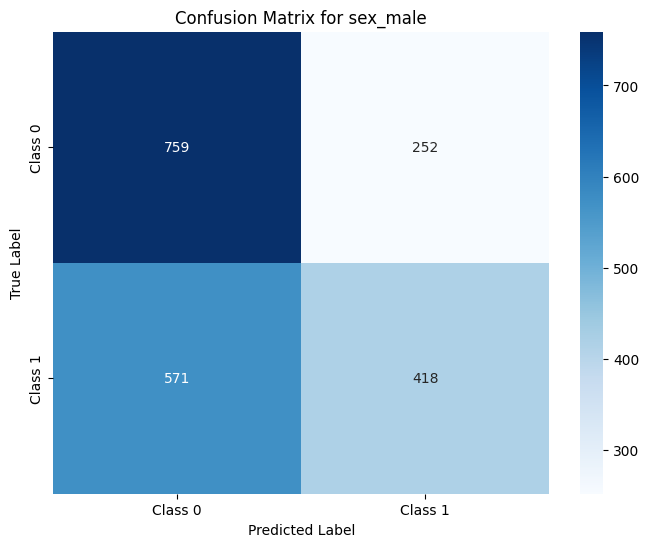

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# AI USAGE: We used AI here to get skeleton code for confusion matrix,
    # then we implemented our code into the skeleton system.


# Assuming 'test' DataFrame and 'test_pred' predictions are already defined

# Replace 'your_column_name' with the actual column name you want to use
column_of_interest = "sex_male"

# Ensure the column exists in your DataFrame
if column_of_interest in test.columns:
    # Create the confusion matrix
    cm = confusion_matrix(test[column_of_interest], test_pred)

    # Define labels for the plot (replace with your actual label names)
    labels = ['Class 0', 'Class 1'] # Replace with meaningful labels for your column

    # Create a heatmap for the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix for {column_of_interest}')
    plt.show()


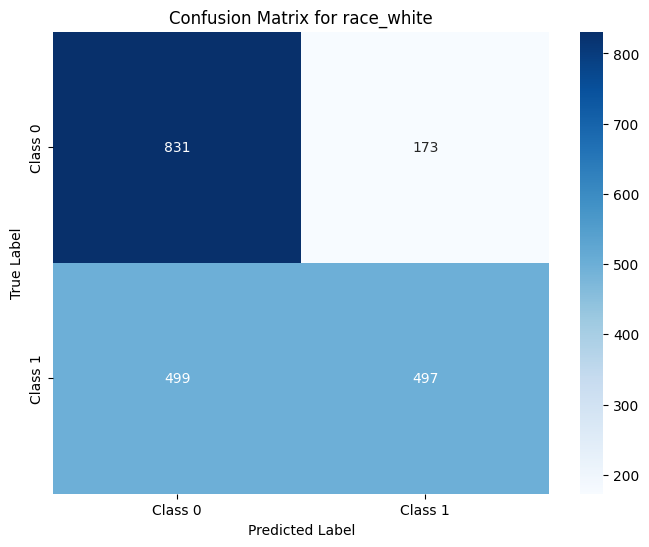

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd


column_of_interest = "race_white"

# Ensure the column exists in your DataFrame
if column_of_interest in test.columns:
    # Create the confusion matrix
    cm = confusion_matrix(test[column_of_interest], test_pred)

    # Define labels for the plot (replace with your actual label names)
    labels = ['Class 0', 'Class 1'] # Replace with meaningful labels for your column

    # Create a heatmap for the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix for {column_of_interest}')
    plt.show()


# Goal: DP Difference = 0 ve DP Ratio = 1

Basicly the model hires white candidates at the same rate as non-white candidates. In other words, the model does not discriminate against non-white candidates compared to white candidates.

eps=0.01 means that the model is very close to being fair, but not perfectly fair. 
We want DP difference to be 0 and DP ratio to be 1.
Note that if we change eps to a larger value, the model will be less fair, and if we change eps to a smaller value, the model will be more fair.
And by changing eps, we can see how the accuracy and fairness trade-off changes.

After training any model (e.g. RandomForest), you can also apply ThresholdOptimizer to its outputs to bring DP closer to zero.

In [19]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from fairlearn.postprocessing import ThresholdOptimizer
import joblib

# Metric Functions
# Metric Functions are created with the help of AI.
def demographic_parity(sens, y_pred):
    sr_p   = np.mean(y_pred[sens==1])
    sr_up  = np.mean(y_pred[sens==0])
    return sr_p - sr_up, (sr_up/sr_p if sr_p else np.nan)

def equalized_odds(sens, y_true, y_pred):
    def rates(mask):
        tn, fp, fn, tp = confusion_matrix(y_true[mask], y_pred[mask]).ravel()
        return tp/(tp+fn), fp/(fp+tn)
    p_mask   = sens==1
    up_mask  = sens==0
    tpr_p, fpr_p = rates(p_mask)
    tpr_u, fpr_u = rates(up_mask)
    return tpr_p - tpr_u, fpr_p - fpr_u

def evaluate(name, y_pred, y_true, sens_dict):
    print(f"\n=== {name} ===")
    print(f"Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")
    for attr, sens in sens_dict.items():
        dp_diff, dp_ratio     = demographic_parity(sens, y_pred)
        eo_tpr_diff, eo_fpr_diff = equalized_odds(sens, y_true, y_pred)
        print(f"{attr:12s} | DP Diff: {dp_diff:6.3f}  DP Ratio: {dp_ratio:6.3f}  "
              f"EO TPR Diff: {eo_tpr_diff:6.3f}  EO FPR Diff: {eo_fpr_diff:6.3f}")
        

# Load Dataset
train_url = "https://raw.githubusercontent.com/CDEIUK/bias-mitigation/refs/heads/master/artifacts/data/recruiting/processed/train.csv"
test_url  = "https://raw.githubusercontent.com/CDEIUK/bias-mitigation/refs/heads/master/artifacts/data/recruiting/processed/test.csv"
df_train  = pd.read_csv(train_url)
df_test   = pd.read_csv(test_url)

y_train = df_train['employed_yes'].values
y_test  = df_test['employed_yes'].values

X_train = df_train.drop(columns=['employed_yes'])
X_test  = df_test.drop(columns=['employed_yes'])

sensitive = {
    "race_white": df_test['race_white'].values,
    "sex_male":   df_test['sex_male'].values
}

# Baseline
clf_base = RandomForestClassifier(random_state=42).fit(X_train, y_train)
joblib.dump(clf_base, "baseline_model.pkl")
y_base   = clf_base.predict(X_test)
evaluate("Baseline RF", y_base, y_test, sensitive)

# Reweighing for each sensitive attribute
for attr in sensitive:
    # prepare AIF360 dataset
    df_aif = df_train.copy()
    df_aif['label'] = df_aif['employed_yes']
    df_aif[attr]    = df_aif[attr].astype(int)
    bld = BinaryLabelDataset(
        df=df_aif, 
        label_names=['label'], 
        protected_attribute_names=[attr]
    )
    rw = Reweighing(
        privileged_groups=[{attr:1}],
        unprivileged_groups=[{attr:0}]
    )
    btr = rw.fit_transform(bld)
    cols = btr.feature_names
    Xrw = pd.DataFrame(btr.features, columns=cols).drop(columns=['employed_yes'], errors='ignore').values
    yrw = btr.labels.ravel()
    wgt = btr.instance_weights
    # train & predict
    clf = RandomForestClassifier(random_state=42)
    clf.fit(Xrw, yrw, sample_weight=wgt)
    joblib.dump(clf, f"reweighing_{attr}.pkl")
    # align test
    Xtest_rw = df_test[cols].drop(columns=['employed_yes'], errors='ignore').values
    y_rw = clf.predict(Xtest_rw)
    evaluate(f"Reweighing ({attr})", y_rw, y_test, sensitive)

# Unawareness (drop both attrs simultaneously)
drop_cols = ['employed_yes','race_white','sex_male']
Xua_train = df_train.drop(columns=drop_cols)
Xua_test  = df_test.drop(columns=drop_cols)
clf_ua    = RandomForestClassifier(random_state=42).fit(Xua_train, y_train)
joblib.dump(clf_ua, "unawareness_model.pkl")
y_ua      = clf_ua.predict(Xua_test)
evaluate("Unawareness", y_ua, y_test, sensitive)

# In-processing (EG) for each attr
for attr in sensitive:
    Xeg_train = df_train.drop(columns=['employed_yes',attr])
    Xeg_test  = df_test.drop(columns=['employed_yes',attr])
    sg_train  = df_train[attr].values
    eg = ExponentiatedGradient(
        estimator=LogisticRegression(solver='liblinear'),
        constraints=DemographicParity(),
        eps=0.01
    )
    eg.fit(Xeg_train, y_train, sensitive_features=sg_train)
    joblib.dump(eg, f"eg_{attr}.pkl")
    y_eg = eg.predict(Xeg_test)
    evaluate(f"EG (eps=0.01) ({attr})", y_eg, y_test, sensitive)

# Post-processing (ThresholdOptimizer) for each attr
for attr in sensitive:
    topt = ThresholdOptimizer(
        estimator=clf_base,
        constraints="demographic_parity",
        prefit=True
    )
    topt.fit(X_test, y_test, sensitive_features=df_test[attr].values)
    joblib.dump(topt, f"postproc_{attr}.pkl")
    y_to = topt.predict(X_test, sensitive_features=df_test[attr].values)
    evaluate(f"Post-proc ({attr})", y_to, y_test, sensitive)


pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[inFairness]'



=== Baseline RF ===
Accuracy: 84.65%
race_white   | DP Diff:  0.333  DP Ratio:  0.355  EO TPR Diff:  0.144  EO FPR Diff:  0.131
sex_male     | DP Diff:  0.162  DP Ratio:  0.625  EO TPR Diff:  0.080  EO FPR Diff:  0.027

=== Reweighing (race_white) ===
Accuracy: 84.25%
race_white   | DP Diff:  0.313  DP Ratio:  0.382  EO TPR Diff:  0.124  EO FPR Diff:  0.112
sex_male     | DP Diff:  0.152  DP Ratio:  0.644  EO TPR Diff:  0.066  EO FPR Diff:  0.021

=== Reweighing (sex_male) ===
Accuracy: 83.65%
race_white   | DP Diff:  0.339  DP Ratio:  0.346  EO TPR Diff:  0.163  EO FPR Diff:  0.144
sex_male     | DP Diff:  0.140  DP Ratio:  0.666  EO TPR Diff:  0.050  EO FPR Diff:  0.014

=== Unawareness ===
Accuracy: 83.10%
race_white   | DP Diff:  0.258  DP Ratio:  0.472  EO TPR Diff:  0.068  EO FPR Diff:  0.058
sex_male     | DP Diff:  0.125  DP Ratio:  0.704  EO TPR Diff:  0.005  EO FPR Diff:  0.018


c:\Users\suuser\AppData\Local\anaconda3\envs\DSA201\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\suuser\AppData\Local\anaconda3\envs\DSA201\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



=== EG (eps=0.01) (race_white) ===
Accuracy: 76.75%
race_white   | DP Diff:  0.009  DP Ratio:  0.975  EO TPR Diff: -0.231  EO FPR Diff: -0.132
sex_male     | DP Diff:  0.230  DP Ratio:  0.499  EO TPR Diff:  0.185  EO FPR Diff:  0.127


c:\Users\suuser\AppData\Local\anaconda3\envs\DSA201\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\suuser\AppData\Local\anaconda3\envs\DSA201\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



=== EG (eps=0.01) (sex_male) ===
Accuracy: 84.25%
race_white   | DP Diff:  0.365  DP Ratio:  0.337  EO TPR Diff:  0.177  EO FPR Diff:  0.168
sex_male     | DP Diff:  0.012  DP Ratio:  0.968  EO TPR Diff: -0.131  EO FPR Diff: -0.095

=== Post-proc (race_white) ===
Accuracy: 79.05%
race_white   | DP Diff:  0.003  DP Ratio:  0.992  EO TPR Diff: -0.289  EO FPR Diff: -0.140
sex_male     | DP Diff:  0.174  DP Ratio:  0.601  EO TPR Diff:  0.111  EO FPR Diff:  0.063


c:\Users\suuser\AppData\Local\anaconda3\envs\DSA201\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\suuser\AppData\Local\anaconda3\envs\DSA201\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\suuser\AppData\Local\anaconda3\envs\DSA201\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



=== Post-proc (sex_male) ===
Accuracy: 83.35%
race_white   | DP Diff:  0.355  DP Ratio:  0.351  EO TPR Diff:  0.164  EO FPR Diff:  0.168
sex_male     | DP Diff:  0.000  DP Ratio:  1.000  EO TPR Diff: -0.140  EO FPR Diff: -0.104


c:\Users\suuser\AppData\Local\anaconda3\envs\DSA201\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


# Explainability


In [ ]:
# AI is used, we found errors we cannot solve. AI used to solve the errors.

import pandas as pd
import numpy as np
import joblib
from lime.lime_tabular import LimeTabularExplainer
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from patra_toolkit import ModelCard, AIModel, Metric
import logging
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing

# Load the data
train_url = "https://raw.githubusercontent.com/CDEIUK/bias-mitigation/refs/heads/master/artifacts/data/recruiting/processed/train.csv"
test_url = "https://raw.githubusercontent.com/CDEIUK/bias-mitigation/refs/heads/master/artifacts/data/recruiting/processed/test.csv"
df_train = pd.read_csv(train_url)
df_test = pd.read_csv(test_url)

# Prepare AIF360 dataset for reweighing (using sex_male as the sensitive attribute)
df_aif = df_train.copy()
df_aif['label'] = df_aif['employed_yes']
df_aif['sex_male'] = df_aif['sex_male'].astype(int)

bld = BinaryLabelDataset(
    df=df_aif, 
    label_names=['label'], 
    protected_attribute_names=['sex_male']
)

# Apply reweighing
rw = Reweighing(
    privileged_groups=[{'sex_male': 1}],
    unprivileged_groups=[{'sex_male': 0}]
)
dataset_transf = rw.fit_transform(bld)

# Extract features and labels from the transformed dataset
feature_names = dataset_transf.feature_names
X_rw_df = pd.DataFrame(dataset_transf.features, columns=feature_names)
if 'employed_yes' in X_rw_df.columns:
    X_rw_df = X_rw_df.drop(columns=['employed_yes'])
X_rw = X_rw_df.values
y_rw = dataset_transf.labels.ravel()
sample_weight = dataset_transf.instance_weights

# Prepare test data with the same columns
X_test_df = df_test[X_rw_df.columns]
X_test = X_test_df.values
y_test = df_test['employed_yes'].values

# Train the reweighted model
from sklearn.ensemble import RandomForestClassifier
clf_rw = RandomForestClassifier(random_state=42)
clf_rw.fit(X_rw, y_rw, sample_weight=sample_weight)
joblib.dump(clf_rw, "reweighing_sex_male.pkl")
print("✅ Re-weighted model saved to reweighing_sex_male.pkl")

# Compute accuracy
y_pred = clf_rw.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Re-weighted Model Accuracy: {acc*100:.2f}%")

# === LIME Local Explanation ===
print("\n=== LIME Explainability ===")

# Build the LIME explainer
explainer_lime = LimeTabularExplainer(
    training_data=X_rw,
    feature_names=X_rw_df.columns.tolist(),
    class_names=['Not Employed', 'Employed'],
    discretize_continuous=False
)

# Pick an example to explain
i = 7
x_i = X_test[i]

# Generate the explanation
exp = explainer_lime.explain_instance(
    data_row=x_i,
    predict_fn=clf_rw.predict_proba,
    num_features=5
)

# Print the top-5 feature weights
print(f"\n🔎 LIME explanation for test instance {i}:")
for feat, weight in exp.as_list():
    print(f"  {feat:30s} {weight:+.4f}")

# === SHAP Global and Local Explanations ===
print("\n=== SHAP Explainability ===")

# Create SHAP explainer
explainer_shap = shap.TreeExplainer(
    clf_rw,
    feature_perturbation="tree_path_dependent"
)

# Calculate SHAP values for the test set
shap_values = explainer_shap.shap_values(
    X_test,
    check_additivity=False
)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    # For binary classification, take the positive class
    shap_values_positive = shap_values[1]
else:
    shap_values_positive = shap_values

# Debug: Check the shape of SHAP values
print(f"SHAP values shape: {shap_values_positive.shape}")
print(f"Expected shape: ({len(X_test)}, {X_test.shape[1]})")

# Ensure SHAP values are 2D (samples x features)
if shap_values_positive.ndim > 2:
    # If 3D, likely shape is (samples, features, classes) - take the last dimension
    shap_values_positive = shap_values_positive[:, :, -1]
    print(f"Adjusted SHAP values shape: {shap_values_positive.shape}")

# 1. Global summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_positive,
    X_test,
    feature_names=X_test_df.columns.tolist(),
    show=False
)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=200, bbox_inches="tight")
plt.close()
print("✅ SHAP summary plot saved to shap_summary.png")

# 2. Local explanation for a specific candidate
cid = 0
pred_prob = clf_rw.predict_proba(X_test[cid:cid+1])[0, 1]

# Extract SHAP values for this specific candidate
candidate_shap_vals = shap_values_positive[cid]
if candidate_shap_vals.ndim > 1:
    candidate_shap_vals = candidate_shap_vals.flatten()

# Configure audit logging
logging.basicConfig(
    filename='audit.log',
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s'
)

def log_prediction(candidate_id, pred, shap_vals, feat_names):
    # Ensure shap_vals is 1D
    if shap_vals.ndim > 1:
        shap_vals = shap_vals.flatten()
    
    top = np.argsort(np.abs(shap_vals))[::-1][:3]
    # Convert numpy indices to Python integers
    top_feats = {feat_names[int(i)]: float(shap_vals[int(i)]) for i in top}
    logging.info(f"Candidate {candidate_id} | pred={pred:.3f} | top_shap={top_feats}")

log_prediction(cid, pred_prob, candidate_shap_vals, list(X_test_df.columns))

# Select top-5 features by absolute SHAP value for visualization
# We already have candidate_shap_vals from above
top_idxs = np.argsort(np.abs(candidate_shap_vals))[::-1][:5]
shap_vals_top5 = np.array([candidate_shap_vals[int(i)] for i in top_idxs])
feat_vals_top5 = np.array([X_test[cid][int(i)] for i in top_idxs])
feat_names_top5 = [X_test_df.columns[int(i)] for i in top_idxs]


if isinstance(explainer_shap.expected_value, list):
    base_value = explainer_shap.expected_value[1]  # For positive class in binary classification
else:
    base_value = explainer_shap.expected_value

# Ensure base_value is a scalar (extract from array if needed)
if isinstance(base_value, np.ndarray):
    if base_value.ndim > 0:
        base_value = base_value[1] if len(base_value) > 1 else base_value[0]
    base_value = float(base_value)

# Create the force plot with the correct API for SHAP v0.20+
force_plot = shap.plots.force(
    base_value,  # Pass as positional argument (first parameter)
    shap_vals_top5,
    feat_vals_top5,
    feature_names=feat_names_top5
)
shap.save_html("shap_local_top5.html", force_plot)
print("SHAP local explanation plot saved to shap_local_top5.html")

# 3. Feature importance plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_positive,
    X_test,
    feature_names=X_test_df.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=200, bbox_inches="tight")
plt.close()
print("SHAP feature importance plot saved to shap_feature_importance.png")

# === Fairness Metrics Computation ===
print("\n=== Fairness Metrics ===")

# Demographic Parity for race
sr_w = y_pred[df_test['race_white'] == 1].mean()
sr_nw = y_pred[df_test['race_white'] == 0].mean()
dpd_race = sr_w - sr_nw
dpr_race = sr_nw / sr_w if sr_w else np.nan

print("\nDemographic Parity (race_white):")
print(f"  Difference: {dpd_race:.3f}")
print(f"  Ratio: {dpr_race:.3f}")

# Demographic Parity for sex
sr_m = y_pred[df_test['sex_male'] == 1].mean()
sr_f = y_pred[df_test['sex_male'] == 0].mean()
dpd_sex = sr_m - sr_f
dpr_sex = sr_f / sr_m if sr_m else np.nan

print("\nDemographic Parity (sex_male):")
print(f"  Difference: {dpd_sex:.3f}")
print(f"  Ratio: {dpr_sex:.3f}")

# Equalized Odds helper function
def tpr_fpr(y_true, y_pred, mask):
    tn, fp, fn, tp = confusion_matrix(y_true[mask], y_pred[mask]).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    return tpr, fpr

# Equalized Odds for race
mask_w = df_test['race_white'] == 1
mask_nw = df_test['race_white'] == 0
tpr_w, fpr_w = tpr_fpr(y_test, y_pred, mask_w)
tpr_nw, fpr_nw = tpr_fpr(y_test, y_pred, mask_nw)
tpr_diff_race = tpr_w - tpr_nw
fpr_diff_race = fpr_w - fpr_nw

print("\nEqualized Odds (race_white):")
print(f"  TPR diff: {tpr_diff_race:.3f}")
print(f"  FPR diff: {fpr_diff_race:.3f}")

# Equalized Odds for sex
mask_m = df_test['sex_male'] == 1
mask_f = df_test['sex_male'] == 0
tpr_m, fpr_m = tpr_fpr(y_test, y_pred, mask_m)
tpr_f, fpr_f = tpr_fpr(y_test, y_pred, mask_f)
tpr_diff_sex = tpr_m - tpr_f
fpr_diff_sex = fpr_m - fpr_f

print("\nEqualized Odds (sex_male):")
print(f"  TPR diff: {tpr_diff_sex:.3f}")
print(f"  FPR diff: {fpr_diff_sex:.3f}")

# === Model Card Creation ===
print("\n=== Creating Model Card ===")

# Create Model Card
card = ModelCard(
    name="RF Re-weighed Hiring Model",
    version="1.0",
    short_description="RandomForest on re-weighted recruiting data for bias mitigation",
    full_description=(
        "RandomForestClassifier trained on CDEIUK re-weighted recruiting data. "
        "Instance weights applied per Kamiran & Calders to mitigate sex-based bias."
    ),
    keywords=["random forest", "fairness", "bias mitigation", "hiring"],
    author="Faraz Badali, Irmak Erkol, Pelin Karadal, Bilgehan Çağıltay",
    input_type="tabular",
    category="classification",
    foundational_model="None"
)

# Create AIModel object
ai_model = AIModel(
    name="RF Re-weighed Hiring Model",
    version="1.0",
    description="RandomForestClassifier trained on re-weighted recruiting data to mitigate sex-based bias",
    owner="team",
    location="reweighing_sex_male.pkl",
    license="BSD-3-Clause",
    framework="sklearn",
    model_type="random_forest",
    test_accuracy=acc
)

# Populate model structure and attach to card
ai_model.populate_model_structure(clf_rw)
card.ai_model = ai_model

# Populate bias metrics for both protected attributes
print("Populating bias metrics for race_white...")
card.populate_bias(
    true_labels=y_test,
    predicted_labels=y_pred,
    sensitive_feature_name="race_white",
    sensitive_feature_data=df_test['race_white'].values,
    model=clf_rw,
    dataset=X_test
)

# Add explainability artifacts to metadata
card.metadata = {
    "explainability_artifacts": {
        "SHAP_summary_plot": "shap_summary.png",
        "SHAP_local_top5_plot": "shap_local_top5.png",
        "SHAP_feature_importance": "shap_feature_importance.png"
    },
    "fairness_metrics": {
        "race_white": {
            "demographic_parity_difference": float(dpd_race),
            "demographic_parity_ratio": float(dpr_race),
            "equalized_odds_tpr_diff": float(tpr_diff_race),
            "equalized_odds_fpr_diff": float(fpr_diff_race)
        },
        "sex_male": {
            "demographic_parity_difference": float(dpd_sex),
            "demographic_parity_ratio": float(dpr_sex),
            "equalized_odds_tpr_diff": float(tpr_diff_sex),
            "equalized_odds_fpr_diff": float(fpr_diff_sex)
        }
    }
}

# Populate requirements
card.populate_requirements()

# Validate and save
card.validate()
card.save("model_card.json")
print("✅ Model card written to model_card.json")

print("\n=== Explainability Section Complete ===")
print("Generated artifacts:")
print("  - reweighing_sex_male.pkl (trained model)")
print("  - shap_summary.png (global feature importance)")
print("  - shap_local_top5.png (local explanation for candidate 0)")
print("  - shap_feature_importance.png (feature importance bar plot)")
print("  - model_card.json (complete model documentation)")
print("  - audit.log (prediction logging)")

✅ Re-weighted model saved to reweighing_sex_male.pkl
Re-weighted Model Accuracy: 83.65%

=== LIME Explainability ===

🔎 LIME explanation for test instance 7:
  years_experience               +0.2406
  referred                       +0.0859
  race_white                     +0.0549
  gcse                           +0.0504
  a_level                        +0.0499

=== SHAP Explainability ===
SHAP values shape: (2000, 13, 2)
Expected shape: (2000, 13)
Adjusted SHAP values shape: (2000, 13)
✅ SHAP summary plot saved to shap_summary.png
✅ SHAP local explanation plot saved to shap_local_top5.html
✅ SHAP feature importance plot saved to shap_feature_importance.png

=== Fairness Metrics ===

Demographic Parity (race_white):
  Difference: 0.339
  Ratio: 0.346

Demographic Parity (sex_male):
  Difference: 0.140
  Ratio: 0.666

Equalized Odds (race_white):
  TPR diff: 0.163
  FPR diff: 0.144

Equalized Odds (sex_male):
  TPR diff: 0.050
  FPR diff: 0.014

=== Creating Model Card ===
Populating bia

# Contestability

In [21]:
import os

print("Current working directory:", os.getcwd())
print("Full path to appeals.log:", os.path.abspath("appeals.log"))


Current working directory: c:\Users\suuser\Desktop\DAE-IRMAK
Full path to appeals.log: c:\Users\suuser\Desktop\DAE-IRMAK\appeals.log


In [22]:
import os
import json
import pandas as pd
import numpy as np
import joblib
import shap
from shap import Explanation
import dice_ml
from dice_ml import Dice
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing


JSONFILE  = os.path.join(os.getcwd(), "appeals.json")
TRAIN_URL = "https://raw.githubusercontent.com/CDEIUK/bias-mitigation/refs/heads/master/artifacts/data/recruiting/processed/train.csv"
TEST_URL  = "https://raw.githubusercontent.com/CDEIUK/bias-mitigation/refs/heads/master/artifacts/data/recruiting/processed/test.csv"

model = joblib.load("reweighing_sex_male.pkl")
df_train = pd.read_csv(TRAIN_URL)
df_test  = pd.read_csv(TEST_URL)
y_test   = df_test["employed_yes"].values

df_aif           = df_train.copy()
df_aif["label"]  = df_aif["employed_yes"]
df_aif["sex_male"]= df_aif["sex_male"].astype(int)
bld = BinaryLabelDataset(
    df=df_aif,
    label_names=["label"],
    protected_attribute_names=["sex_male"]
)
rw  = Reweighing(
    privileged_groups=[{"sex_male":1}],
    unprivileged_groups=[{"sex_male":0}]
)
btr = rw.fit_transform(bld)
cols   = btr.feature_names
X_test = df_test[cols].drop(columns=["employed_yes"], errors="ignore")

model.feature_names_in_ = X_test.columns.values

explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")

dice_data = dice_ml.Data(
    dataframe=pd.concat([X_test, pd.Series(y_test, name="employed_yes")], axis=1),
    continuous_features=X_test.columns.tolist(),
    outcome_name="employed_yes"
)
dice_exp = Dice(
    dice_data,
    dice_ml.Model(model=model, backend="sklearn"),
    method="random"
)

cid_w      = widgets.BoundedIntText(
    value=0, min=0, max=len(X_test)-1, description="Applicant ID:"
)
explain_b  = widgets.Button(description="Explain Decision", button_style="info")
appeal_ta  = widgets.Textarea(placeholder="Describe your concern…", description="Appeal:")
submit_b   = widgets.Button(description="Submit Appeal", button_style="warning")
check_b    = widgets.Button(description="Check Appeal Status", button_style="success")
out        = widgets.Output()
status_out = widgets.Output()

def on_explain(_):
    with out:
        clear_output()
        cid = cid_w.value
        row = X_test.iloc[[cid]]

        # Hiring probability
        prob = model.predict_proba(row)[0,1]
        print(f" Hiring probability: {prob:.1%}\n")

        # SHAP bar chart
        raw = explainer.shap_values(row, check_additivity=False)
        sv  = raw[1][0] if isinstance(raw, list) else raw[0]
        sv_arr = np.asarray(sv)
        if sv_arr.ndim > 1:
            sv_arr = sv_arr.sum(axis=tuple(range(1, sv_arr.ndim)))
        idxs  = np.argsort(np.abs(sv_arr))[::-1][:10]
        names = X_test.columns.to_numpy()[idxs][::-1]
        vals  = sv_arr[idxs][::-1]
        pos   = np.arange(len(vals))
        plt.figure(figsize=(6,4))
        plt.barh(pos, vals)
        plt.yticks(pos, names)
        plt.xlabel("SHAP impact")
        plt.title(f"Top-10 SHAP (Gender-Reweighted) for ID={cid}")
        plt.tight_layout()
        plt.show()

        # Counterfactual recourse
        cf = dice_exp.generate_counterfactuals(
            row, total_CFs=3, desired_class="opposite"
        )
        print("🔄 Counterfactual suggestions:\n")
        display(cf.cf_examples_list[0].final_cfs_df)

def on_submit(_):
    with out:
        clear_output()
        reason = appeal_ta.value.strip()
        if not reason:
            print("Please enter a reason for your appeal.")
            return

        # load or init appeals list
        if os.path.exists(JSONFILE):
            appeals = json.load(open(JSONFILE))
        else:
            appeals = []

        ts  = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
        cid = cid_w.value
        appeals.append({
            "timestamp"        : ts,
            "scenario"         : "Gender-Reweighted",
            "applicant_id"     : cid,
            "reason"           : reason,
            "status"           : "",
            "reviewer_comments": "",
            "reviewed_at"      : ""
        })

        # write back to JSON
        with open(JSONFILE, "w") as f:
            json.dump(appeals, f, indent=2)

        print(f"Appeal submitted for Applicant {cid} at {ts}")
        appeal_ta.value = ""

def on_check(_):
    with status_out:
        clear_output()
        if not os.path.exists(JSONFILE):
            print("No appeals found yet.")
            return

        appeals = json.load(open(JSONFILE))
        my_id    = cid_w.value
        decisions = [
            a for a in appeals
            if a["applicant_id"] == my_id and a["status"]
        ]

        if not decisions:
            print("No decision yet. Please check again later.")
        else:
            for a in decisions:
                print(f"Decision: {a['status']}  (reviewed at {a['reviewed_at']})")
                print(f"   Reviewer notes: {a['reviewer_comments']!r}\n")

explain_b.on_click(on_explain)
submit_b.on_click(on_submit)
check_b.on_click(on_check)

display(widgets.VBox([
    cid_w,
    explain_b,
    widgets.HTML("<hr style='margin:10px 0;'>"),
    appeal_ta,
    submit_b,
    check_b,
    widgets.HTML("<hr style='margin:10px 0;'>"),
    out,
    status_out
]))


In [23]:
import os, json, datetime
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

JSONFILE = os.path.join(os.getcwd(), "appeals.json")

# Load appeals
with open(JSONFILE, "r") as f:
    appeals = json.load(f)
df = pd.DataFrame(appeals)

# Build widgets
case_w = widgets.Select(
  options=[
    (f"{i}: {r.scenario} | ID {r.applicant_id} → {r.reason[:30]}…", i)
    for i,r in df.iterrows() if r["status"]==""
  ],
  rows=6, description="Unreviewed:"
)
status_w = widgets.RadioButtons(options=["Approved","Denied"], description="Decision:")
notes_w  = widgets.Textarea(description="Notes…")
save_b   = widgets.Button(description="Save", button_style="primary")
out      = widgets.Output()

# Show details
def on_case_change(change):
  with out:
    clear_output()
    i = change["new"]
    if i is None: return
    r = df.loc[i]
    print(f" {r.timestamp}\n✏{r.reason}\n")
case_w.observe(on_case_change, names="value")

# Save back to JSON
def on_save(_):
  i = case_w.value
  if i is None:
    with out: print(" No case selected."); return
  df.at[i, "status"] = status_w.value
  df.at[i, "reviewer_comments"] = notes_w.value
  df.at[i, "reviewed_at"] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
  # write JSON
  with open(JSONFILE, "w") as f:
    json.dump(df.to_dict("records"), f, indent=2)
  with out:
    clear_output()
    print(f" Case {i} marked {status_w.value}.")
    # refresh dropdown
    remaining = [
      (f"{j}: {r.scenario} → {r.reason[:30]}…", j)
      for j,r in df.iterrows() if r["status"]==""
    ]
    case_w.options = remaining
    notes_w.value = ""
save_b.on_click(on_save)

display(widgets.VBox([case_w, widgets.HBox([status_w, save_b]), notes_w, out]))
